In [2]:
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

In [3]:
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
MERGED_DIR = PROJECT_ROOT / "datasets" / "MERGED"

CLASSES = ["Music", "Speech", "Other"]

if not MERGED_DIR.exists():
    print(f"Error: Dataset directory does not exist: {MERGED_DIR}")

## 1. Feature extraction

In [4]:
def extract_features(file_path):
    try:
        y, sr = librosa.load(file_path, sr=None)
    except Exception as e:
        return {"error": str(e)}
        
    duration = librosa.get_duration(y=y, sr=sr)
        
    rms = np.mean(librosa.feature.rms(y=y))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y=y))
    
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfccs_mean = np.mean(mfccs, axis=1)
    
    tempo_array = librosa.feature.tempo(y=y, sr=sr)
    tempo = tempo_array[0] if len(tempo_array) > 0 else 0
    
    y_harmonic, y_percussive = librosa.effects.hpss(y)
    harm_eng = np.sum(y_harmonic**2)
    perc_eng = np.sum(y_percussive**2)
    
    if perc_eng > 0:
        hnr = 10 * np.log10(harm_eng / perc_eng)
    else:
        hnr = 100.0
        
    features = {
        "duration": duration,
        "rms": rms,
        "zcr": zcr,
        "tempo": tempo,
        "hnr_db": hnr
    }
    
    for i in range(13):
        features[f"mfcc_{i+1}"] = mfccs_mean[i]
        
    return features

In [5]:
import multiprocessing
from joblib import Parallel, delayed

files_to_process = []
for cls in CLASSES:
    cls_dir = MERGED_DIR / cls
    if cls_dir.exists():
        class_files = list(cls_dir.glob("*.wav"))
        print(f"{cls}: {len(class_files)} files")
        for wav_file in class_files:
            prefix = wav_file.stem.split('_')[0]
            files_to_process.append((wav_file, cls, prefix))
    else:
        print(f"Missing class directory: {cls_dir}")

total_files = len(files_to_process)
n_cores = multiprocessing.cpu_count()
print(f"Total files to process: {total_files} (using {n_cores} CPU cores for maximum speed...)")

if total_files == 0:
    raise RuntimeError(
        f"No WAV files found under {MERGED_DIR}. Check PROJECT_ROOT/MERGED_DIR settings."
    )

def process_single_file(item):
    wav_file, cls, prefix = item
    feats = extract_features(wav_file)
    feats["filename"] = wav_file.name
    feats["class"] = cls
    feats["source"] = prefix
    return feats

data_records = Parallel(n_jobs=-1, verbose=5)(
    delayed(process_single_file)(item) for item in files_to_process
)

valid_df = pd.DataFrame(data_records)
valid_df.head()

Music: 527 files
Speech: 53 files
Other: 948 files
Total files to process: 1528 (using 32 CPU cores for maximum speed...)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    6.4s
[Parallel(n_jobs=-1)]: Done  98 tasks      | elapsed:   10.8s
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:   16.5s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   23.5s
[Parallel(n_jobs=-1)]: Done 584 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done 818 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done 1088 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done 1394 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done 1528 out of 1528 | elapsed:  2.0min finished


,duration,rms,zcr,tempo,hnr_db,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,...,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,filename,class,source
0,30.013333,0.130184,0.083045,123.046875,1.561403,-113.598824,121.570671,-19.162262,42.363941,-6.362266,...,-13.699734,15.339802,-12.274304,10.970945,-8.326061,8.802088,-3.669941,gtzan_blues.00000.wav,Music,gtzan
1,30.013333,0.095908,0.056040,107.666016,2.213624,-207.523834,123.985138,8.947019,35.867149,2.909595,...,-8.556513,23.370676,-10.103608,11.899242,-5.558824,5.377876,-2.234492,gtzan_blues.00001.wav,Music,gtzan
2,30.013333,0.175473,0.076291,161.499023,3.403841,-90.757164,140.440872,-29.084547,31.686693,-13.976547,...,-13.664990,11.634442,-11.778322,9.714756,-13.125314,5.791247,-8.901966,gtzan_blues.00002.wav,Music,gtzan
3,30.013333,0.141040,0.033309,172.265625,8.468222,-199.575134,150.086105,5.663404,26.855278,1.770071,...,-4.827845,9.286853,-0.756120,8.134435,-3.200026,6.078081,-2.478445,gtzan_blues.00003.wav,Music,gtzan
4,30.013333,0.091501,0.101461,135.999178,1.919788,-160.354172,126.209480,-35.581394,22.139256,-32.473549,...,-23.350071,0.493249,-11.796538,1.203519,-13.084959,-2.810499,-6.934471,gtzan_blues.00004.wav,Music,gtzan


## 2. Basic validation

In [6]:
short_files = valid_df[valid_df['duration'] < 4]
print(f"Too short files (< 4s): {len(short_files)}")

silent_files = valid_df[valid_df['rms'] < 0.0001]
print(f"Near-silent recordings (RMS < 0.0001): {len(silent_files)}")


Too short files (< 4s): 193
Near-silent recordings (RMS < 0.0001): 1


In [7]:
short_source_class_counts = (
    short_files.groupby(["source", "class"])
    .size()
    .reset_index(name="samples")
    .sort_values("samples", ascending=False)
)
display(short_source_class_counts)

print(short_files)
print("\n Silent files:")
print(silent_files)

,source,class,samples
0,musan,Other,193


      duration       rms       zcr       tempo     hnr_db      mfcc_1  \
606   2.912187  0.201227  0.024510  117.187500  12.900376 -131.913773   
613   0.904312  0.250741  0.360840  133.928571   0.009878   49.210960   
639   2.986500  0.187996  0.205078  110.294118  -5.874411  -98.191185   
648   1.544500  0.149997  0.126076  125.000000  -4.286766 -200.030197   
649   3.415938  0.186184  0.155378  117.187500   0.100884 -287.901520   
...        ...       ...       ...         ...        ...         ...   
1511  2.063000  0.340292  0.100083  110.294118  21.897982 -276.483185   
1515  2.063000  0.007382  0.226262  170.454545 -30.615835 -641.880737   
1523  3.604000  0.101456  0.383767  125.000000 -15.217801 -375.787872   
1526  2.063000  0.154088  0.162906   81.521739 -25.800293 -287.224396   
1527  0.552000  0.038954  0.149333  117.187500 -78.595970 -497.859314   

          mfcc_2      mfcc_3     mfcc_4     mfcc_5  ...     mfcc_7     mfcc_8  \
606   121.182159   31.371967  17.056856  -

## 3. Basic feature analysis

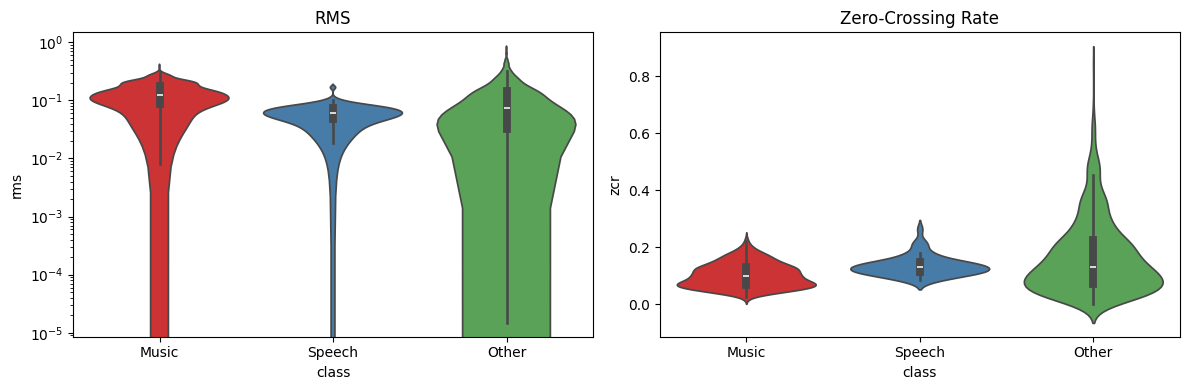

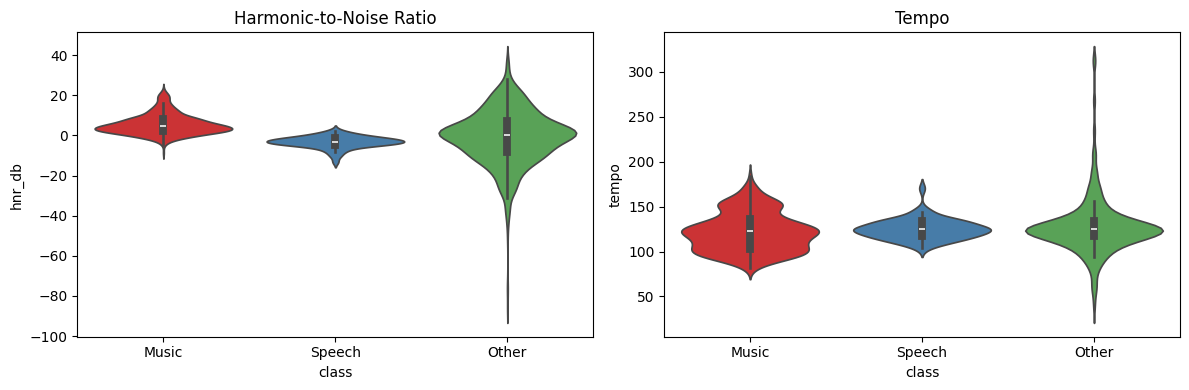

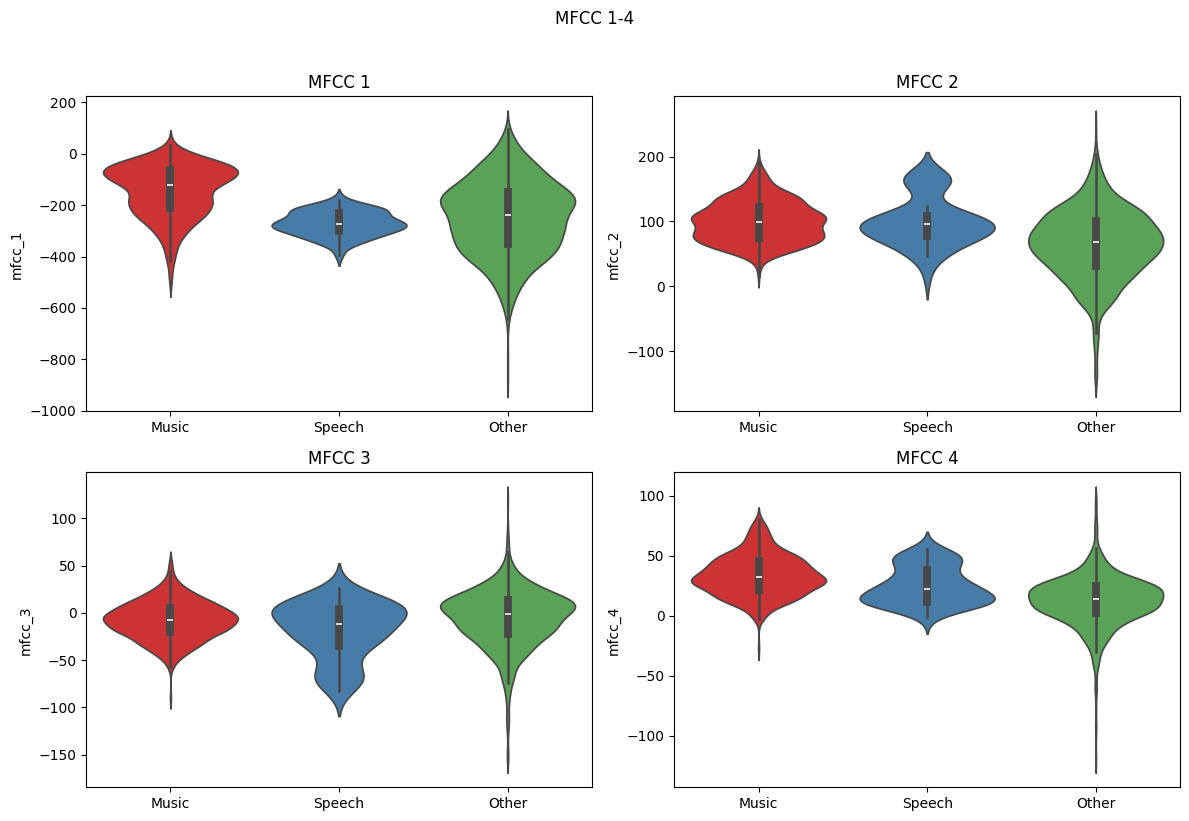

In [8]:

# Plot 1: RMS and ZCR
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.violinplot(data=valid_df, x='class', y='rms', palette="Set1", ax=axes[0])
axes[0].set_title("RMS")
axes[0].set_yscale('log')

sns.violinplot(data=valid_df, x='class', y='zcr', palette="Set1", ax=axes[1])
axes[1].set_title("Zero-Crossing Rate")

plt.tight_layout()
plt.show()

# Plot 2: HNR and Tempo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.violinplot(data=valid_df, x='class', y='hnr_db', palette="Set1", ax=axes[0])
axes[0].set_title("Harmonic-to-Noise Ratio")

sns.violinplot(data=valid_df, x='class', y='tempo', palette="Set1", ax=axes[1])
axes[1].set_title("Tempo")

plt.tight_layout()
plt.show()

# Plot 3: MFCC 1-4 
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, ax in enumerate(axes.flat, start=1):
    sns.violinplot(data=valid_df, x='class', y=f'mfcc_{i}', palette="Set1", ax=ax)
    ax.set_title(f"MFCC {i}")
    ax.set_xlabel("")

plt.suptitle("MFCC 1-4", y=1.02)
plt.tight_layout()
plt.show()


## Correlation between metrics

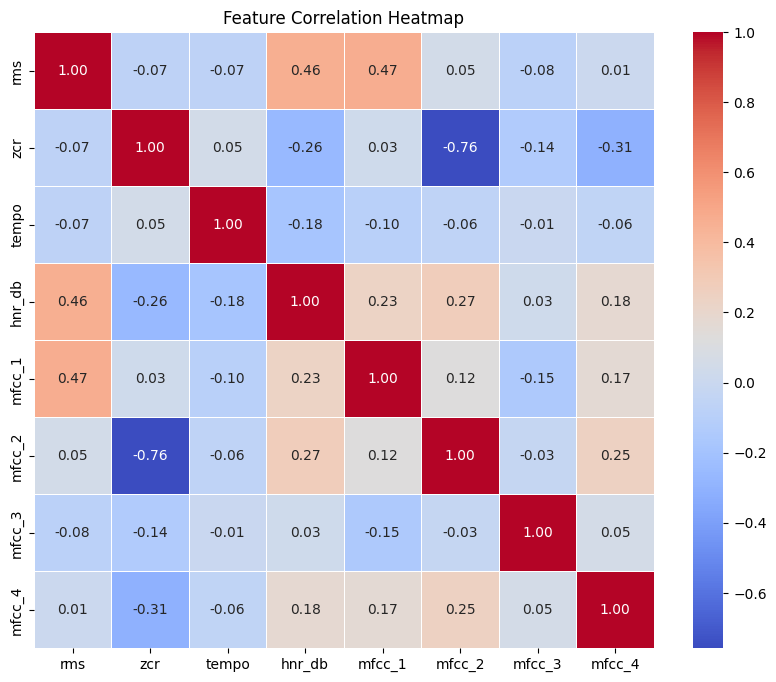

In [9]:
corr_cols = ['rms', 'zcr', 'tempo', 'hnr_db', 'mfcc_1', 'mfcc_2', 'mfcc_3', 'mfcc_4']
corr_matrix = valid_df[corr_cols].corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

## 5. Per source analysis

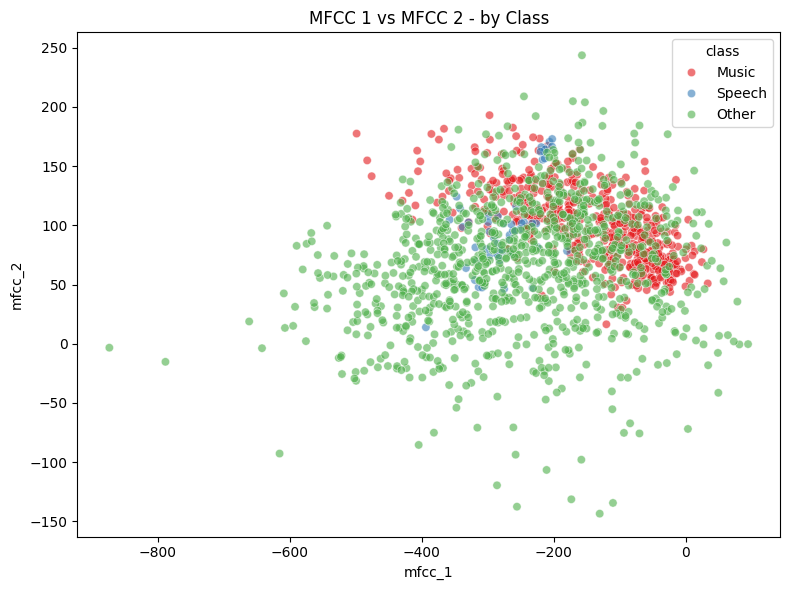

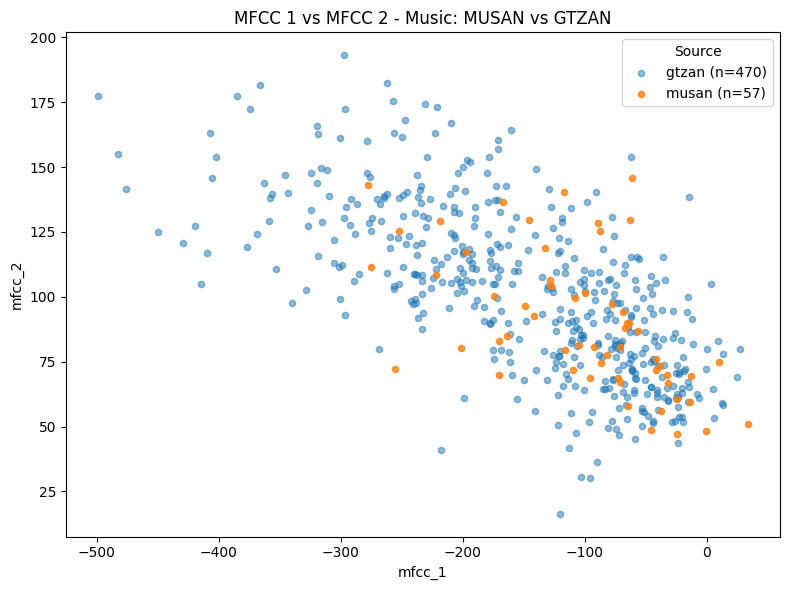

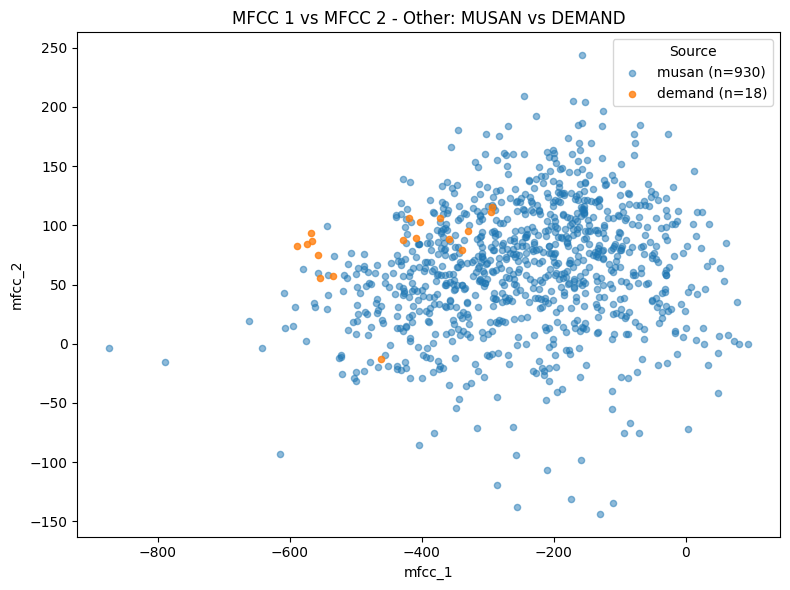

Analysis Generation Complete.


In [10]:
def layered_scatter(ax, data, x, y, source_a, source_b):
    n_a = (data['source'].str.lower() == source_a.lower()).sum()
    n_b = (data['source'].str.lower() == source_b.lower()).sum()

    if n_a >= n_b:
        bg_src, fg_src = source_a, source_b
    else:
        bg_src, fg_src = source_b, source_a

    bg = data[data['source'].str.lower() == bg_src.lower()]
    fg = data[data['source'].str.lower() == fg_src.lower()]

    ax.scatter(bg[x], bg[y], s=20, alpha=0.5, label=f"{bg_src} (n={len(bg)})", rasterized=True)
    ax.scatter(fg[x], fg[y], s=20, alpha=0.8, label=f"{fg_src} (n={len(fg)})", rasterized=True)
    ax.legend(title='Source')

# 1) All data - by class
plt.figure(figsize=(8, 6))
sns.scatterplot(data=valid_df, x='mfcc_1', y='mfcc_2', hue='class', alpha=0.6, palette="Set1")
plt.title("MFCC 1 vs MFCC 2 - by Class")
plt.tight_layout()
plt.show()

# 2) Music - MUSAN vs GTZAN
music_src = valid_df[
    (valid_df['class'] == 'Music') &
    (valid_df['source'].str.lower().isin(['musan', 'gtzan']))
]
fig, ax = plt.subplots(figsize=(8, 6))
layered_scatter(ax, music_src, 'mfcc_1', 'mfcc_2', 'musan', 'gtzan')
ax.set_title("MFCC 1 vs MFCC 2 - Music: MUSAN vs GTZAN")
ax.set_xlabel('mfcc_1')
ax.set_ylabel('mfcc_2')
plt.tight_layout()
plt.show()

# 3) Other - MUSAN vs DEMAND
other_src = valid_df[
    (valid_df['class'] == 'Other') &
    (valid_df['source'].str.lower().isin(['musan', 'demand']))
]
fig, ax = plt.subplots(figsize=(8, 6))
layered_scatter(ax, other_src, 'mfcc_1', 'mfcc_2', 'musan', 'demand')
ax.set_title("MFCC 1 vs MFCC 2 - Other: MUSAN vs DEMAND")
ax.set_xlabel('mfcc_1')
ax.set_ylabel('mfcc_2')
plt.tight_layout()
plt.show()

print("Analysis Generation Complete.")


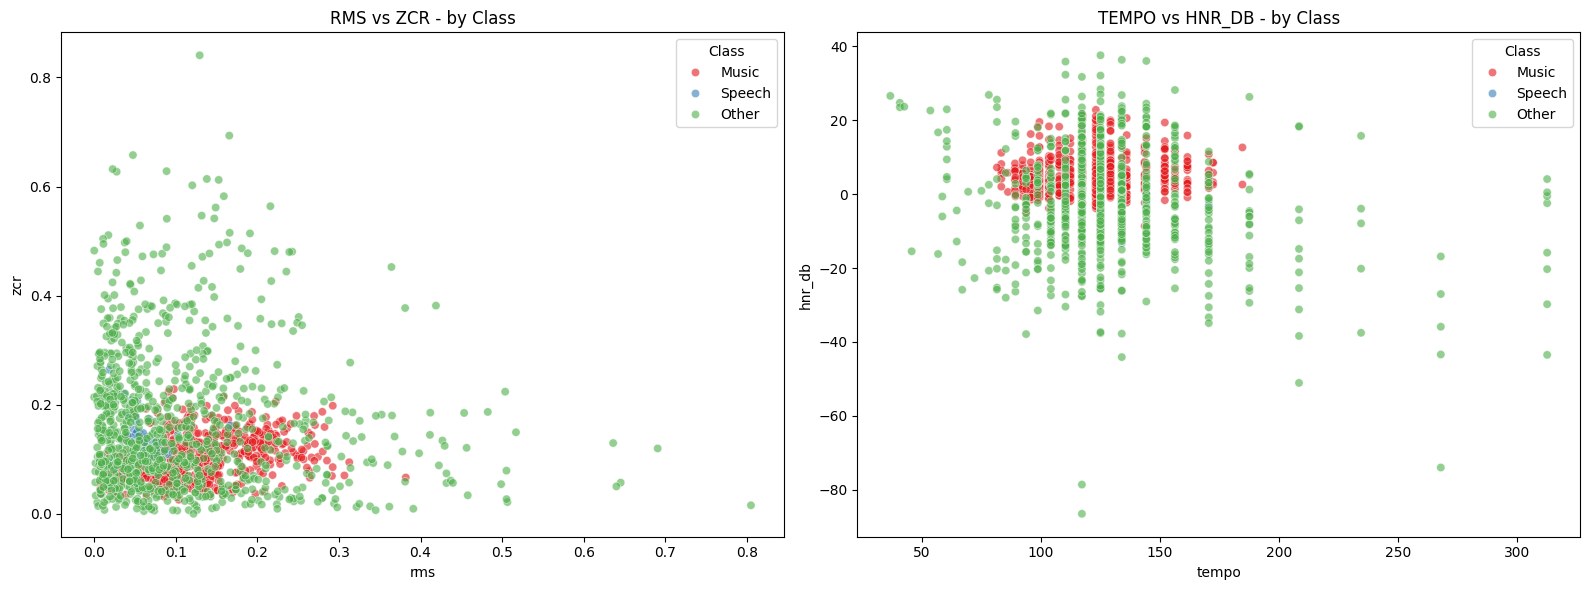

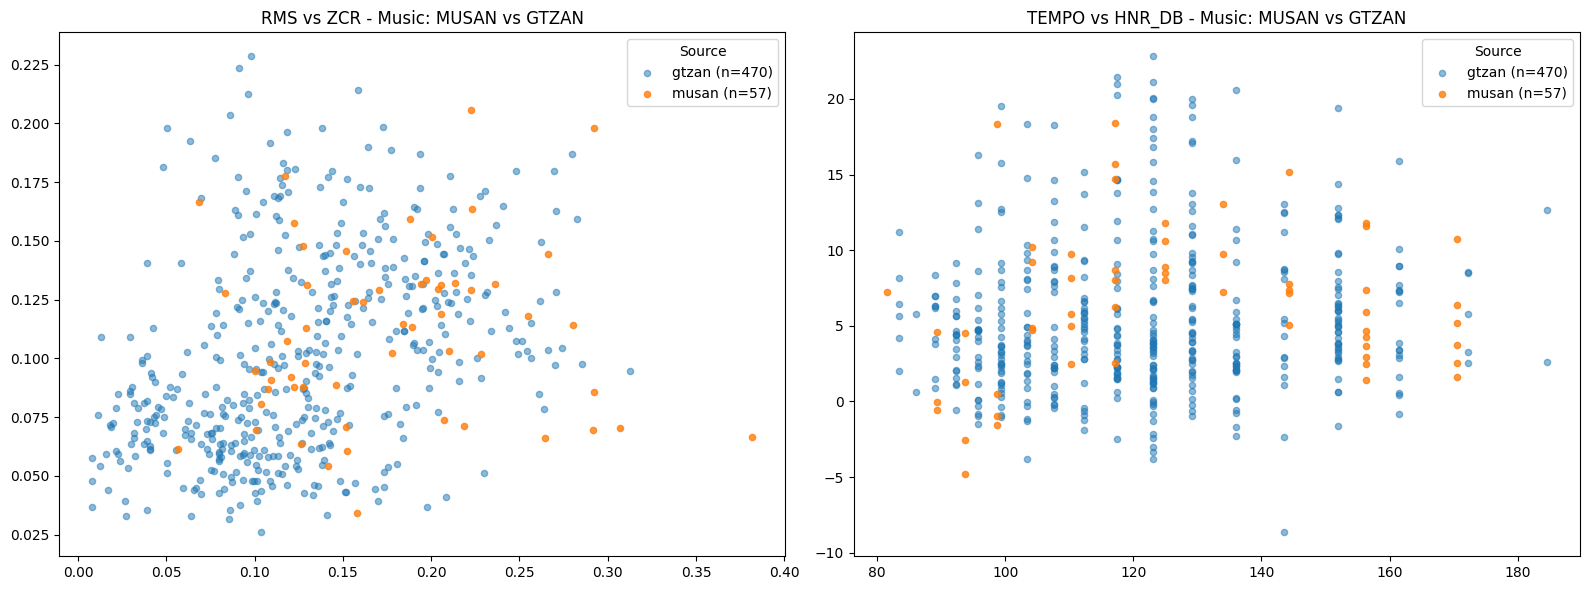

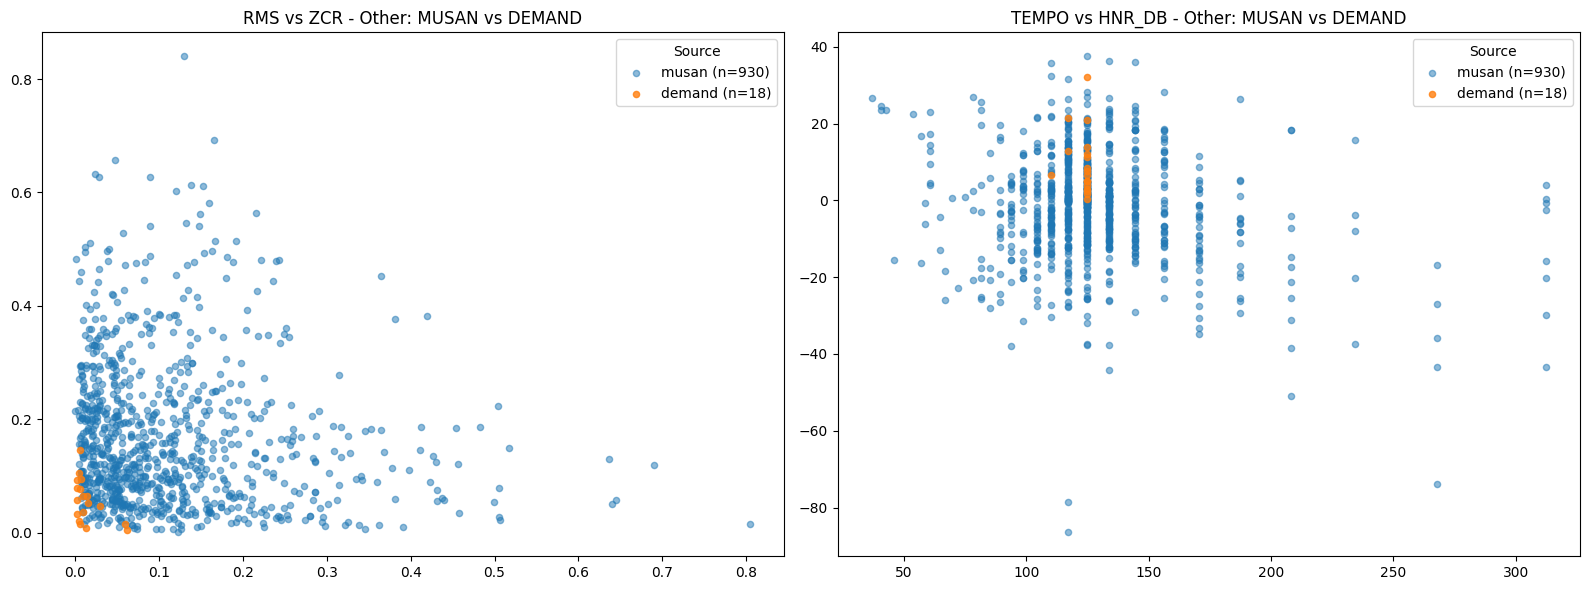

In [11]:

music_src = valid_df[
    (valid_df['class'] == 'Music') &
    (valid_df['source'].str.lower().isin(['musan', 'gtzan']))
]
other_src = valid_df[
    (valid_df['class'] == 'Other') &
    (valid_df['source'].str.lower().isin(['musan', 'demand']))
]

feature_pairs = [('rms', 'zcr'), ('tempo', 'hnr_db')]

# Plot 1: by Class
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for col_idx, (x_feat, y_feat) in enumerate(feature_pairs):
    sns.scatterplot(data=valid_df, x=x_feat, y=y_feat,
                    hue='class', alpha=0.6, ax=axes[col_idx], palette="Set1")
    axes[col_idx].set_title(f"{x_feat.upper()} vs {y_feat.upper()} - by Class")
    axes[col_idx].legend(title='Class')
plt.tight_layout()
plt.show()

# Plot 2: Music - MUSAN vs GTZAN
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for col_idx, (x_feat, y_feat) in enumerate(feature_pairs):
    layered_scatter(axes[col_idx], music_src, x_feat, y_feat, 'musan', 'gtzan')
    axes[col_idx].set_title(f"{x_feat.upper()} vs {y_feat.upper()} - Music: MUSAN vs GTZAN")
plt.tight_layout()
plt.show()

# Plot 3: Other - MUSAN vs DEMAND
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for col_idx, (x_feat, y_feat) in enumerate(feature_pairs):
    layered_scatter(axes[col_idx], other_src, x_feat, y_feat, 'musan', 'demand')
    axes[col_idx].set_title(f"{x_feat.upper()} vs {y_feat.upper()} - Other: MUSAN vs DEMAND")
plt.tight_layout()
plt.show()


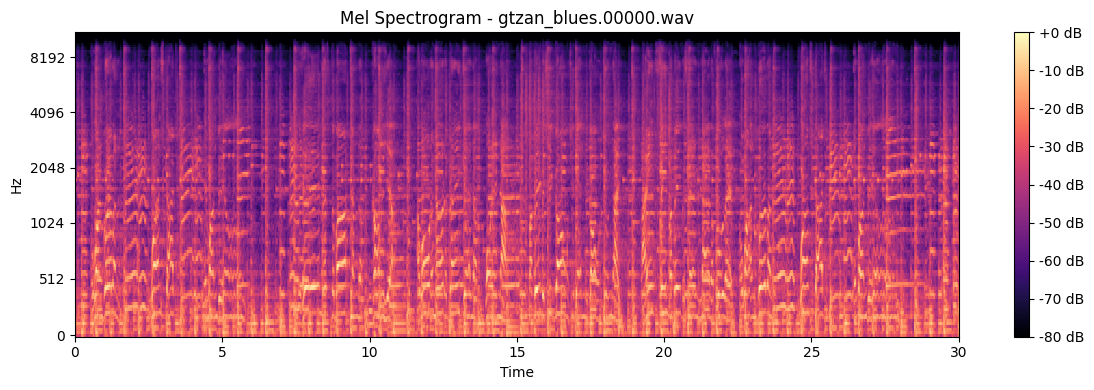

In [12]:
first_music_item = next((item for item in files_to_process if item[1] == "Music"), None)
first_music_path = first_music_item[0]
y, sr = librosa.load(first_music_path, sr=None)

S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=sr // 2)
S_db = librosa.power_to_db(S, ref=np.max)

plt.figure(figsize=(12, 4))
librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="mel", fmax=sr // 2)
plt.colorbar(format="%+2.0f dB")
plt.title(f"Mel Spectrogram - {first_music_path.name}")
plt.tight_layout()
plt.show()

GTZAN Music samples: 470
genre
gtzan_blues        47
gtzan_classical    47
gtzan_country      47
gtzan_disco        47
gtzan_hiphop       47
gtzan_jazz         47
gtzan_metal        47
gtzan_pop          47
gtzan_reggae       47
gtzan_rock         47


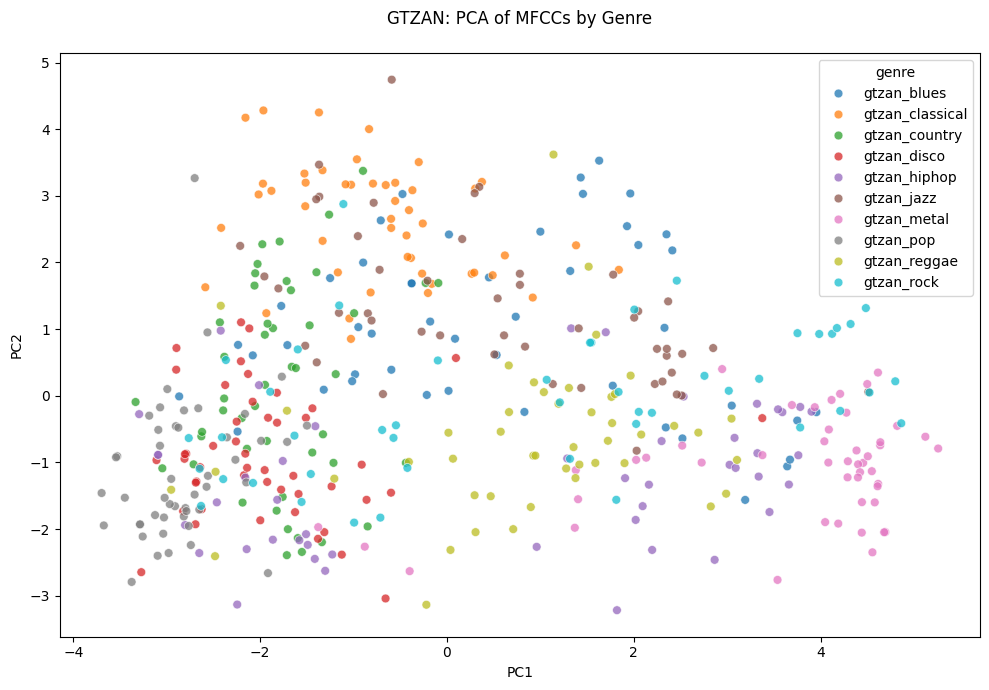

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

mfcc_cols = [f"mfcc_{i}" for i in range(1, 14)]

gtzan_music = valid_df[
    (valid_df["class"] == "Music") &
    (valid_df["source"].str.lower() == "gtzan")
].copy()

gtzan_music["genre"] = gtzan_music["filename"].apply(
    lambda f: f.split(".")[0].lower()
)

print(f"GTZAN Music samples: {len(gtzan_music)}")
print(gtzan_music["genre"].value_counts().to_string())

X = gtzan_music[mfcc_cols].dropna()
genres = gtzan_music.loc[X.index, "genre"]
X_scaled = StandardScaler().fit_transform(X)

# PCA scatter
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
gtzan_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"], index=X.index)
gtzan_pca["genre"] = genres

plt.figure(figsize=(10, 7))
sns.scatterplot(data=gtzan_pca, x="PC1", y="PC2", hue="genre",
                palette="tab10", alpha=0.75, s=40)
plt.title(
    f"GTZAN: PCA of MFCCs by Genre\n"
)
plt.tight_layout()
plt.show()
